In [1]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.constants import mu_0


In [2]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


Ajuste lineal corriente vs B 


Pendiente = 18.670559083840775 ± 0.004262185854115794 mT/A
Intercepto = -1.474048816288567 ± 0.007991865568983967 mT


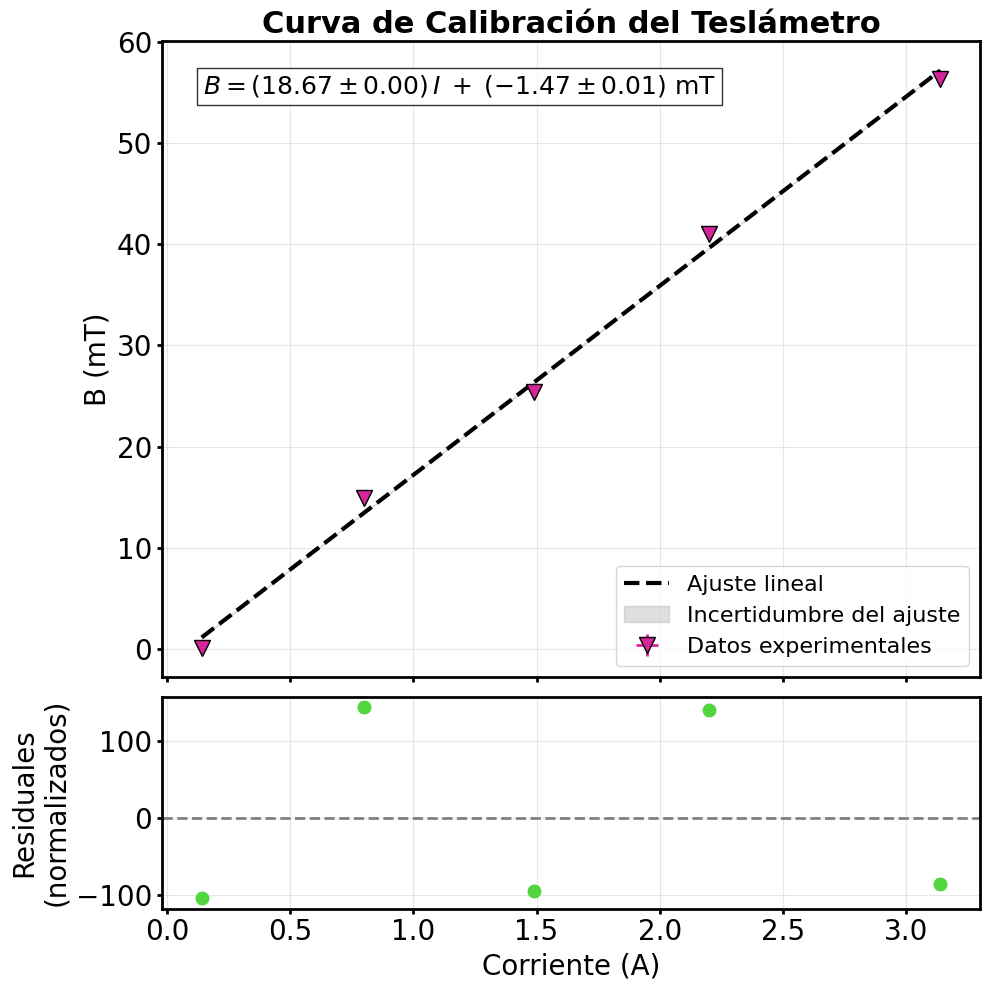

In [3]:
# ======================================================
#   DATOS DE CALIBRACIÓN (3 reales + 2 inventados)
# ======================================================

I_cal = np.array([0.14, 0.80, 1.49, 2.20, 3.14])
B_cal_mT = np.array([0.1, 14.9, 25.4, 41.0, 56.3])

# Errores instrumentales
err_I = np.ones_like(I_cal) * 0.01      # 0.01 A
err_B = np.ones_like(B_cal_mT) * 0.01   # 0.01 mT


# ======================================================
#   AJUSTE LINEAL PONDERADO: B = m I + b
# ======================================================

def ajuste_lineal(I, B_mT, err_B):
    """
    Ajuste lineal ponderado:
    B = m I + b
    usando pesos w = 1/sigma_B^2
    """

    w = 1 / err_B**2

    S   = np.sum(w)
    Sx  = np.sum(w * I)
    Sy  = np.sum(w * B_mT)
    Sxx = np.sum(w * I**2)
    Sxy = np.sum(w * I * B_mT)

    Delta = S * Sxx - Sx**2

    m = (S * Sxy - Sx * Sy) / Delta
    b = (Sxx * Sy - Sx * Sxy) / Delta

    # Errores
    dm = np.sqrt(S / Delta)
    db = np.sqrt(Sxx / Delta)

    return m, b, dm, db


# Ejecutar ajuste
m, b, dm, db = ajuste_lineal(I_cal, B_cal_mT, err_B)

print("Pendiente =", m, "±", dm, "mT/A")
print("Intercepto =", b, "±", db, "mT")


# ======================================================
#   CURVA DE AJUSTE Y RESIDUALES
# ======================================================

I_aj = np.linspace(I_cal.min(), I_cal.max(), 300)
B_aj = m * I_aj + b

residuales_norm = (B_cal_mT - (m * I_cal + b)) / err_B


# ======================================================
#   BANDA DE INCERTIDUMBRE DEL AJUSTE
# ======================================================

# Var(B) = I^2 * dm^2 + db^2   (propagación de error)
sigma_B_aj = np.sqrt((I_aj**2) * (dm**2) + db**2)

B_upper = B_aj + sigma_B_aj
B_lower = B_aj - sigma_B_aj


# ======================================================
#   FUNCIÓN DE GRÁFICA ESTILO PREMIUM
# ======================================================
def plot_ajuste_calibracion(I, B, err_I, err_B, I_aj, B_aj,
                             residuales_norm, m, b, dm, db,
                             color_n1="#D6259B", color_n2="#51D63F"):

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ------------------ Panel principal ------------------
    ax1.set_title("Curva de Calibración del Teslámetro",
                fontsize=22, weight="bold")
    ax1.set_ylabel("B (mT)", fontsize=20)
    ax1.tick_params(axis="both", labelsize=20, width=2)
    ax1.grid(True, alpha=0.3)

    for spine in ax1.spines.values():
        spine.set_linewidth(2)

    # === Barras de error (x & y) ===
    ax1.errorbar(
        I, B, xerr=err_I, yerr=err_B,
        fmt="v", markersize=11, mfc=color_n1, mec="black",
        elinewidth=2, capthick=2, color=color_n1,
        label="Datos experimentales"
    )

    # === Recta de ajuste ===
    ax1.plot(I_aj, B_aj, "--", linewidth=3, color="black",
            label="Ajuste lineal")

    # === Banda de incertidumbre del ajuste ===
    ax1.fill_between(
        I_aj,
        B_lower,
        B_upper,
        color="gray",
        alpha=0.25,
        label="Incertidumbre del ajuste"
    )

    # === Ecuación del ajuste ===
    ax1.text(
        0.05, 0.95,
        rf"$B = ({m:.2f} \pm {dm:.2f})\,I \;+\; ({b:.2f} \pm {db:.2f})$ mT",
        transform=ax1.transAxes,
        fontsize=18,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

    ax1.legend(fontsize=16)


    # ------------------ Panel de residuales ------------------
    ax2.set_xlabel("Corriente (A)", fontsize=20)
    ax2.set_ylabel("Residuales\n(normalizados)", fontsize=20)
    ax2.tick_params(axis="both", labelsize=20, width=2)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    # === Residuales con barras de error en x & y ===
    ax2.errorbar(
        I, residuales_norm,
        xerr=err_I,
        yerr=np.ones_like(residuales_norm),
        fmt='o',
        color=color_n2,
        markersize=9,
        capsize=4,
        linewidth=1.8,
        ecolor="gray",
        elinewidth=1.6,
        zorder=4,
        label="Residuales"
    )

    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



# ======================================================
#   LLAMAR LA FUNCIÓN DE GRAFICADO
# ======================================================

plot_ajuste_calibracion(
    I_cal, B_cal_mT, err_I, err_B,
    I_aj, B_aj,
    residuales_norm, m, b, dm, db
)


Creacion de graficas con histeresis y demas

In [4]:
def plot_secuencia_datos(
        x, y,
        titulo="Secuencia de Toma de Datos",
        xlabel="Posición X",
        ylabel="Posición Y",
        color_arrows="black",
        color_points="#D6259B",
        arrow_scale=0.25,
        point_size=40,
        xerr=None,
        yerr=None,
        xlim=None,
        ylim=None):

    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor("#F7F9FB")

    # -------------------------
    # Flechas entre puntos
    # -------------------------
    for i in range(len(x) - 1):
        ax.annotate(
            "",
            xy=(x[i+1], y[i+1]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="-|>", 
                lw=1.2,
                color=color_arrows,
                shrinkA=arrow_scale,
                shrinkB=arrow_scale
            )
        )
    
    # -------------------------
    # Dibujar barras de error (si existen)
    # -------------------------
    if (xerr is not None) or (yerr is not None):
        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt='none',
            ecolor="gray",
            elinewidth=1.6,
            capsize=4,
            zorder=3
        )

    # -------------------------
    # Puntos
    # -------------------------
    ax.scatter(
        x, y,
        s=point_size,
        color=color_points,
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    

    # -------------------------
    # Estética — ESTILO PREMIUM
    # -------------------------
    ax.set_title(titulo, fontsize=22, weight="bold")     # TÍTULO GRANDE
    ax.set_xlabel(xlabel, fontsize=20)                   # ETIQUETA X GRANDE
    ax.set_ylabel(ylabel, fontsize=20)                   # ETIQUETA Y GRANDE

    ax.tick_params(axis="both", labelsize=18, width=2)   # TICKS GRANDES

    ax.grid(True, alpha=0.25)

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    # Bordes
    for spine in ax.spines.values():
        spine.set_color("#444")
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()


In [ ]:
# Errores instrumentales
SIGMA_I = 0.01 ; SIGMA_B = 0.01e-3   

def ajustar_campo_magnetico(I_datos, B_datos):
    I_cal = np.array([0.14, 1.49, 3.14]);  B_cal = np.array([0.1, 25.4, 56.3]) * 1e-3         


    I_all = np.concatenate([I_datos, I_cal])
    B_all = np.concatenate([B_datos, B_cal])

    # ==========================
    # 3) PESOS (1/sigma^2)
    # ==========================
    # Para tus datos: error instrumental
    sigma_B_datos = np.full_like(I_datos, SIGMA_B, dtype=float)

    # Para calibración: más peso (menor incertidumbre)
    factor_mas_peso = 0.5  # la mitad de la incertidumbre → 4 veces más peso
    sigma_B_cal = np.full_like(I_cal, SIGMA_B * factor_mas_peso, dtype=float)

    sigma_all = np.concatenate([sigma_B_datos, sigma_B_cal])
    w = 1.0 / sigma_all**2  # ¡CORRECCIÓN: pesos son 1/sigma^2!

    # ==========================
    # 4) AJUSTE LINEAL PONDERADO
    # ==========================
    # B = m I + b
    coef, cov = np.polyfit(I_all, B_all, 1, w=w, cov=True)
    pendiente, intercepto = coef
    sigma_m = np.sqrt(cov[0, 0])
    sigma_b = np.sqrt(cov[1, 1])

    # ==========================
    # 5) RESIDUALES Y ESTADÍSTICAS
    # ==========================
    B_ajus_all = np.polyval(coef, I_all)
    residuales = B_all - B_ajus_all
    chi2 = np.sum((residuales / sigma_all)**2)
    grados_libertad = len(I_all) - 2
    chi2_reducido = chi2 / grados_libertad

    # ==========================
    # 6) FIGURA: ajuste + residuales
    # ==========================
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 14), gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- Puntos de tus datos ---
    ax1.errorbar(I_datos, B_datos, yerr=sigma_B_datos, fmt='o', 
                 color="royalblue", markersize=5, capsize=3,
                 label="Datos lab (I, B)")

    # --- Puntos de calibración ---
    ax1.errorbar(I_cal, B_cal, yerr=sigma_B_cal, fmt='s', 
                 color="darkred", markersize=6, capsize=4,
                 label="Calibración teslámetro")

    # --- Recta ajustada ---
    I_line = np.linspace(0, 1.1 * I_all.max(), 300)
    B_line = np.polyval(coef, I_line)
    ax1.plot(I_line, B_line, "black", linewidth=2, label="Ajuste lineal")

    # Estética general
    ax1.set_title("Ajuste lineal ponderado del campo magnético", fontsize=14, weight="bold")
    ax1.set_xlabel("Corriente I (A)", fontsize=12)
    ax1.set_ylabel("Campo B (T)", fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # --- Texto con parámetros ---
    texto_param = f"Pendiente: ({pendiente:.4f} ± {sigma_m:.4f}) T/A\n"
    texto_param += f"Intercepto: ({intercepto:.5f} ± {sigma_b:.5f}) T\n"
    texto_param += f"χ²/ν = {chi2_reducido:.2f}"
    
    ax1.text(0.05, 0.95, texto_param, transform=ax1.transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # --- Residuales ---
    ax2.errorbar(I_all, residuales, yerr=sigma_all, fmt='o', 
                 color="purple", markersize=4, capsize=3, alpha=0.7)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Corriente I (A)")
    ax2.set_ylabel("Residuales (T)")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ==========================
    # 7) IMPRIMIR RESULTADOS
    # ==========================
    print("=" * 50)
    print("RESULTADOS DEL AJUSTE LINEAL")
    print("=" * 50)
    print(f"Pendiente (m): {pendiente:.6f} ± {sigma_m:.6f} T/A")
    print(f"Intercepto (b): {intercepto:.6f} ± {sigma_b:.6f} T")
    print(f"χ² = {chi2:.2f}")
    print(f"Grados de libertad = {grados_libertad}")
    print(f"χ² reducido = {chi2_reducido:.2f}")
    print("=" * 50)

    return pendiente, sigma_m, intercepto, sigma_b

In [6]:
niquel = leer_columnas('Niquel.txt')
hierro = leer_columnas('Hierro.txt')


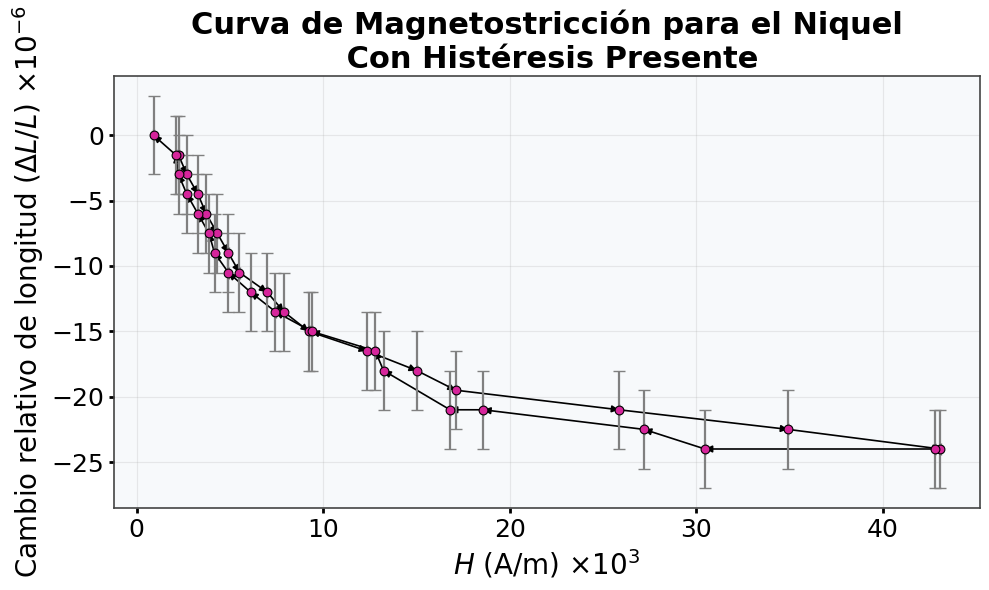

In [7]:
# ---- Calibración ----
m = 18.67       # mT/A
b = -1.47       # mT
mu_0 = 4*np.pi*1e-7

# ---- Datos del níquel ----
I_n = niquel[0]        # Corriente (A)
orden = niquel[1]      # Órdenes de interferencia

# ============================
# 1. B(I) desde la regresión
# ============================
B_mT = m*I_n + b                # mT
B_tesla = B_mT * 1e-3           # T

# ============================
# 2. Convertir B -> H
# ============================
H = B_tesla / mu_0              # A/m

# ---- ERROR en H ----
sigma_B_tesla = 0.01e-3         # 0.01 mT -> T
sigma_H = sigma_B_tesla / mu_0  # A/m


# ============================
# 3. Calcular ΔL/L
# ============================
lambda_n = 6e-9                 # m (6 nm)
delta_l = lambda_n * orden / 2  # m
l = 0.1                         # m
delta_rel = delta_l / l         # ΔL/L

# ---- ERROR EN ΔL/L ----
sigma_n = 1                     # ±1 franja
sigma_delta_l = lambda_n/2 * sigma_n
sigma_delta_rel = sigma_delta_l / l


# ============================
# 4. Graficar con errores
# ============================

plot_secuencia_datos(
    H*1e-3,                     # H en unidades de 10^3 A/m
    delta_rel*1e8,             # ΔL/L en 10^-6
    titulo="Curva de Magnetostricción para el Niquel\n Con Histéresis Presente",
    xlabel = r"$H$ (A/m) $\times 10^{3}$",
    ylabel = r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$",
    arrow_scale=0.15,
    xerr = sigma_H * 1e-3,     # errores en x
    yerr = sigma_delta_rel*1e8  # errores en y
)


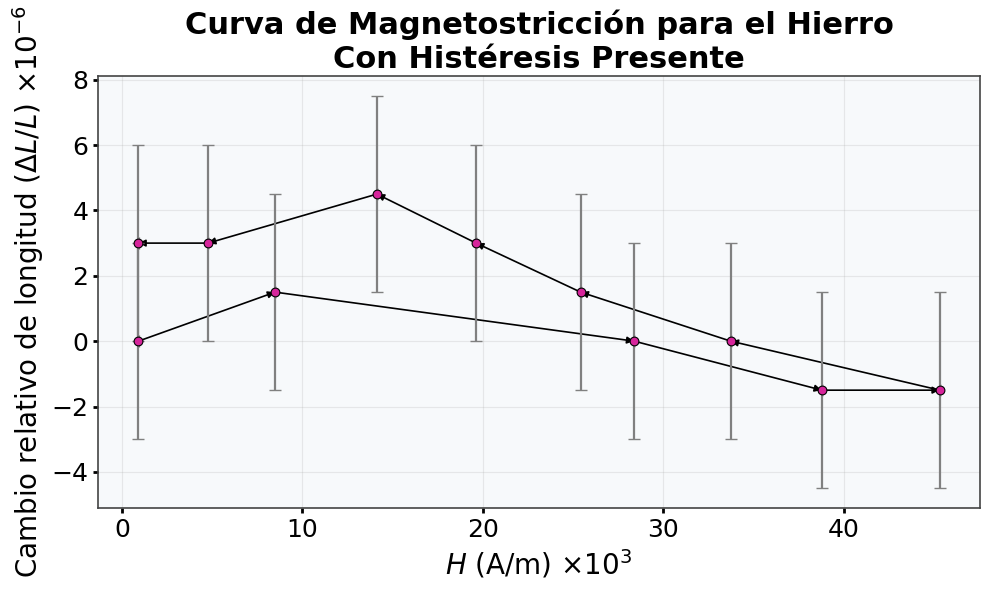

In [8]:
# ---- Calibración ----
m = 18.67       # mT/A
b = -1.47       # mT
mu_0 = 4*np.pi*1e-7

# ---- Datos del hierro ----
I_n = hierro[0][26:37]     # Corriente (A)
orden = hierro[1][26:37]   # Órdenes de interferencia

# ============================
# 1. B(I) desde regresión
# ============================
B_mT = m * I_n + b
B_tesla = B_mT * 1e-3

# ============================
# 2. H y su error
# ============================
sigma_I = 0.01             # A
sigma_B = 0.01e-3          # T  (0.01 mT)

H = B_tesla / mu_0
sigma_H = sigma_B / mu_0   # A/m

# ============================
# 3. ΔL/L y su error
# ============================
lambda_n = 6e-9
delta_l = lambda_n * orden / 2
l = 0.1

delta_rel = delta_l / l

# error del interferómetro = ± 1 franja
sigma_delta_l = lambda_n/2
sigma_delta_rel = sigma_delta_l / l


# ============================
# 4. Graficar con errores
# ============================

plot_secuencia_datos(
    H * 1e-3,
    delta_rel * 1e8,
    xerr = sigma_H * 1e-3,
    yerr = sigma_delta_rel * 1e8,
    titulo="Curva de Magnetostricción para el Hierro\nCon Histéresis Presente",
    xlabel = r"$H$ (A/m) $\times 10^{3}$",
    ylabel = r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$",
    arrow_scale=0.15,
)



In [9]:
import numpy as np

# ------------------------------
# Parámetros físicos
# ------------------------------
lambda_n = 6e-9   # longitud de onda del láser (6 nm)
L_barra = 0.10    # longitud de la barra (0.10 m)

# ------------------------------
# Datos: número de mínimos (n)
# Esto lo puedes reemplazar por tus datos reales
# Ejemplo:
# n_minimos = hierro[1][26:37]
# ------------------------------
n_minimos = np.array(orden)   # si ya cargaste "orden" antes

# ------------------------------
# Cálculo del cambio de longitud
# Ecuación (1.1): ΔL = λ n / 2
# ------------------------------
delta_L = (lambda_n * n_minimos) / 2    # en metros

# ------------------------------
# También puedes obtener el cambio relativo ΔL/L
# ------------------------------
delta_L_rel = delta_L / L_barra

# ------------------------------
# Imprimir resultados
# ------------------------------
for i, n in enumerate(n_minimos):
    print(f"n = {n:>3}  →  ΔL = {delta_L[i]:.3e} m   |   ΔL/L = {delta_L_rel[i]:.3e}")


n = 0.0  →  ΔL = 0.000e+00 m   |   ΔL/L = 0.000e+00
n = 0.5  →  ΔL = 1.500e-09 m   |   ΔL/L = 1.500e-08
n = 0.0  →  ΔL = 0.000e+00 m   |   ΔL/L = 0.000e+00
n = -0.5  →  ΔL = -1.500e-09 m   |   ΔL/L = -1.500e-08
n = -0.5  →  ΔL = -1.500e-09 m   |   ΔL/L = -1.500e-08
n = 0.0  →  ΔL = 0.000e+00 m   |   ΔL/L = 0.000e+00
n = 0.5  →  ΔL = 1.500e-09 m   |   ΔL/L = 1.500e-08
n = 1.0  →  ΔL = 3.000e-09 m   |   ΔL/L = 3.000e-08
n = 1.5  →  ΔL = 4.500e-09 m   |   ΔL/L = 4.500e-08
n = 1.0  →  ΔL = 3.000e-09 m   |   ΔL/L = 3.000e-08
n = 1.0  →  ΔL = 3.000e-09 m   |   ΔL/L = 3.000e-08
